In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
import einops
iris = load_iris()

In [11]:
X = iris.data
y = iris.target
device = 'cuda' if torch.cuda.is_available() else 'cpu'

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)


class IrisDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = IrisDataset(X, y)
split=0.9

train_dataset = IrisDataset(X[:int(len(X)*split)], y[:int(len(X)*split)])
test_dataset = IrisDataset(X[int(len(X)*split):], y[int(len(X)*split):])

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True
)


# example usage
for X_batch, y_batch in train_loader:
    print(X_batch)   # (batch_size, 4)
    print(y_batch)   # (batch_size,)
    break

tensor([[6.3000, 3.3000, 4.7000, 1.6000],
        [4.6000, 3.6000, 1.0000, 0.2000],
        [6.7000, 3.3000, 5.7000, 2.1000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [6.5000, 3.0000, 5.8000, 2.2000],
        [6.4000, 2.9000, 4.3000, 1.3000],
        [5.0000, 3.4000, 1.5000, 0.2000],
        [7.7000, 3.8000, 6.7000, 2.2000],
        [5.2000, 2.7000, 3.9000, 1.4000],
        [5.0000, 3.4000, 1.6000, 0.4000],
        [5.9000, 3.0000, 4.2000, 1.5000],
        [5.6000, 2.8000, 4.9000, 2.0000],
        [7.0000, 3.2000, 4.7000, 1.4000],
        [4.5000, 2.3000, 1.3000, 0.3000],
        [7.2000, 3.2000, 6.0000, 1.8000],
        [5.7000, 3.0000, 4.2000, 1.2000],
        [7.1000, 3.0000, 5.9000, 2.1000],
        [5.1000, 3.7000, 1.5000, 0.4000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [6.9000, 3.1000, 4.9000, 1.5000],
        [5.8000, 2.8000, 5.1000, 2.4000],
        [6.0000, 2.2000, 5.0000, 1.5000],
        [6.5000, 3.0000, 5.5000, 1

In [12]:
print(len(train_loader.dataset))
print(len(test_loader.dataset))

135
15


In [72]:
class k_means_trainer:
    def __init__(self, 
                 k: int, 
                 train_loader: DataLoader, 
                 test_loader: DataLoader,
                 initialization_method: str = 'random') -> None:
        self.k = k
        self.train_loader = train_loader
        self.test_loader = test_loader
        
        if initialization_method == 'random':
            random_idxs = torch.randint(low=0, high=len(train_loader.dataset), size=(k,))
            self.centroids, _ = train_loader.dataset[random_idxs]
            print(f"self.centroids = {self.centroids}")
            print(f"shape: {self.centroids.shape}")
        else:
            raise NotImplementedError()
        
    def _assign_clusters(self, batch: torch.Tensor)->torch.Tensor:
        asquared = einops.reduce(self.centroids**2, 'k n -> 1 k', reduction='sum')  # [1, k]
        bsquared = einops.reduce(batch**2, 'b n -> b 1', reduction='sum')           # [b, 1]
        prod = 2 * einops.einsum(batch, self.centroids, 'b n, k n -> b k')          # [b, k]

        distances = asquared + bsquared - prod  # [b, k]
        class_labels = torch.argmin(distances, dim=1)  # [b]
        return class_labels
        
    def predict(self, loader: DataLoader) -> float:
        # build cluster→label mapping from train data
        cluster_labels = torch.zeros(self.k, self.k)
        for batch, labels in self.train_loader:
            clusters = self._assign_clusters(batch)
            for c in range(self.k):
                for l in range(self.k):
                    cluster_labels[c, l] += ((clusters == c) & (labels == l)).sum()
        mapping = cluster_labels.argmax(dim=1)

        # evaluate
        correct, total = 0, 0
        for batch, labels in loader:
            preds = mapping[self._assign_clusters(batch)]
            correct += (preds == labels).sum().item()
            total += labels.shape[0]
        return correct / max(total, 1)

        
    def fit(self, max_steps: int = 100) -> None:
        # (a - b)^2 = a^2 + b^2 - 2ab
        for step in range(max_steps):
            centroid_sums = torch.zeros_like(self.centroids)  # [k, n]
            centroid_counts = torch.zeros(self.k)             # [k]

            for batch, labels in self.train_loader:
                class_labels = self._assign_clusters(batch)
               
                for klass in range(self.k):
                    mask = class_labels == klass
                    if mask.sum() == 0:
                        continue
                    centroid_sums[klass] += batch[mask].sum(dim=0)
                    centroid_counts[klass] += mask.sum()


            # update centroids once per step using full dataset
            for klass in range(self.k):
                if centroid_counts[klass] == 0:
                    continue
                self.centroids[klass] = centroid_sums[klass] / centroid_counts[klass]
            
            print(f"step {step} train acc: {self.predict(train_loader)}, test acc: {self.predict(test_loader)}")
            
         

In [73]:
trainer = k_means_trainer(
    k=3,
    train_loader=train_loader,
    test_loader=test_loader
)

trainer.fit()

self.centroids = tensor([[4.9000, 2.4000, 3.3000, 1.0000],
        [7.9000, 3.8000, 6.4000, 2.0000],
        [7.6000, 3.0000, 6.6000, 2.1000]])
shape: torch.Size([3, 4])
step 0 train acc: 0.6222222222222222, test acc: 0.06666666666666667
step 1 train acc: 0.7777777777777778, test acc: 0.2
step 2 train acc: 0.8518518518518519, test acc: 0.3333333333333333
step 3 train acc: 0.9037037037037037, test acc: 0.6666666666666666
step 4 train acc: 0.9185185185185185, test acc: 0.7333333333333333
step 5 train acc: 0.9185185185185185, test acc: 0.7333333333333333
step 6 train acc: 0.9111111111111111, test acc: 0.7333333333333333
step 7 train acc: 0.9111111111111111, test acc: 0.7333333333333333
step 8 train acc: 0.9111111111111111, test acc: 0.7333333333333333
step 9 train acc: 0.9111111111111111, test acc: 0.7333333333333333
step 10 train acc: 0.9111111111111111, test acc: 0.7333333333333333
step 11 train acc: 0.9111111111111111, test acc: 0.7333333333333333
step 12 train acc: 0.9111111111111111,

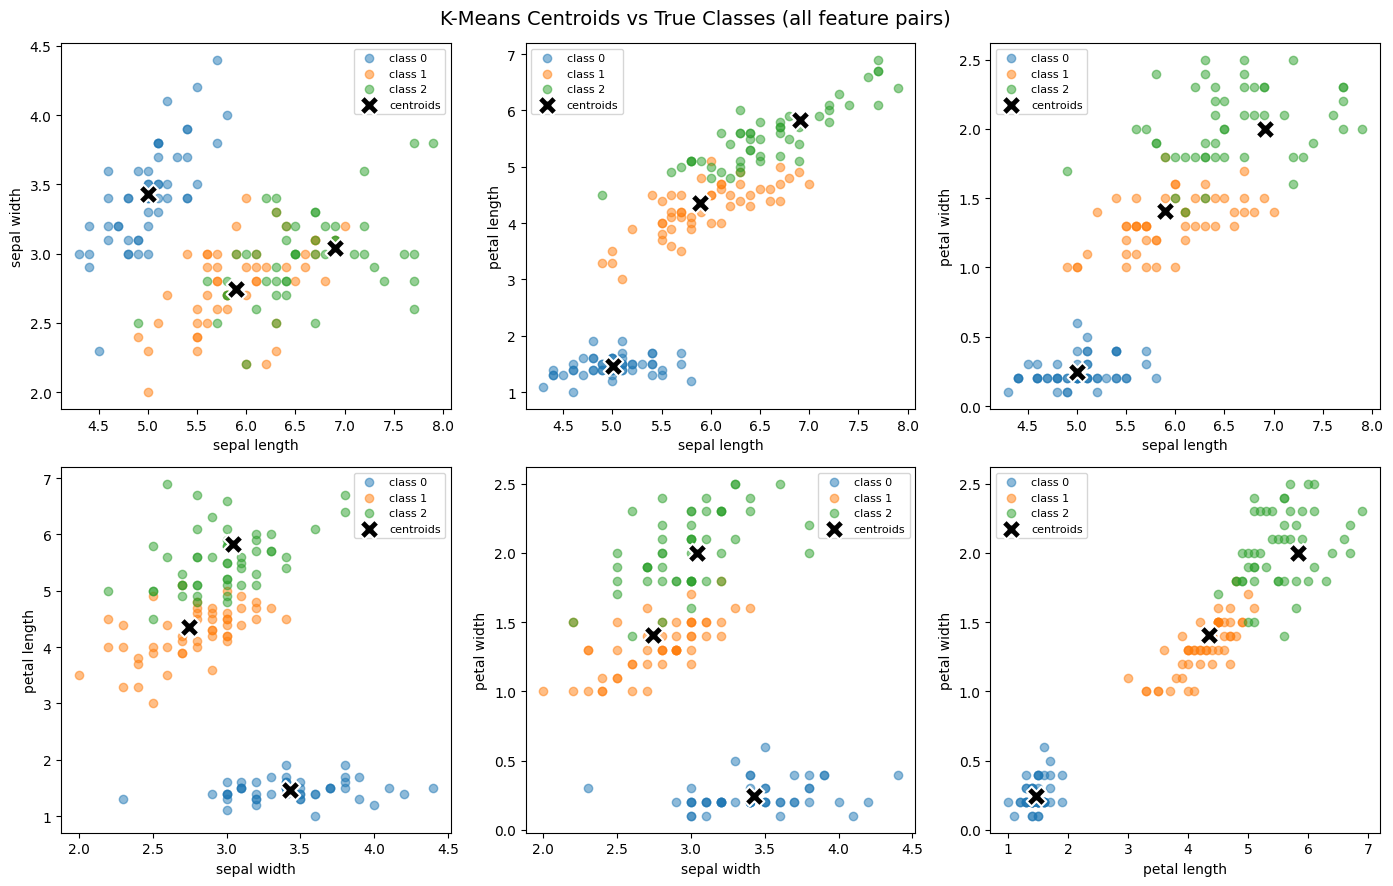

In [74]:
import matplotlib.pyplot as plt
import itertools

feature_names = ['sepal length', 'sepal width', 'petal length', 'petal width']
pairs = list(itertools.combinations(range(4), 2))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

X_np = X.numpy()
y_np = y.numpy()
centroids_np = trainer.centroids.detach().numpy()

for idx, (i, j) in enumerate(pairs):
    ax = axes[idx]
    for label in range(3):
        mask = y_np == label
        ax.scatter(X_np[mask, i], X_np[mask, j], alpha=0.5, label=f'class {label}')
    ax.scatter(centroids_np[:, i], centroids_np[:, j], 
               c='black', marker='X', s=200, edgecolors='white', linewidths=1.5, 
               label='centroids', zorder=5)
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    ax.legend(fontsize=8)

plt.suptitle('K-Means Centroids vs True Classes (all feature pairs)', fontsize=14)
plt.tight_layout()
plt.show()